# Geographic distribution 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_08_investor_transactions.csv")


In [6]:
# SIP transactions only

sip = df[
    df["transaction_type"].str.upper() == "SIP"
].copy()

# Ensure amount is numeric
sip["amount_inr"] = pd.to_numeric(
    sip["amount_inr"],
    errors="coerce"
)

state_sip = (
    sip.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=False)
       .reset_index()
)

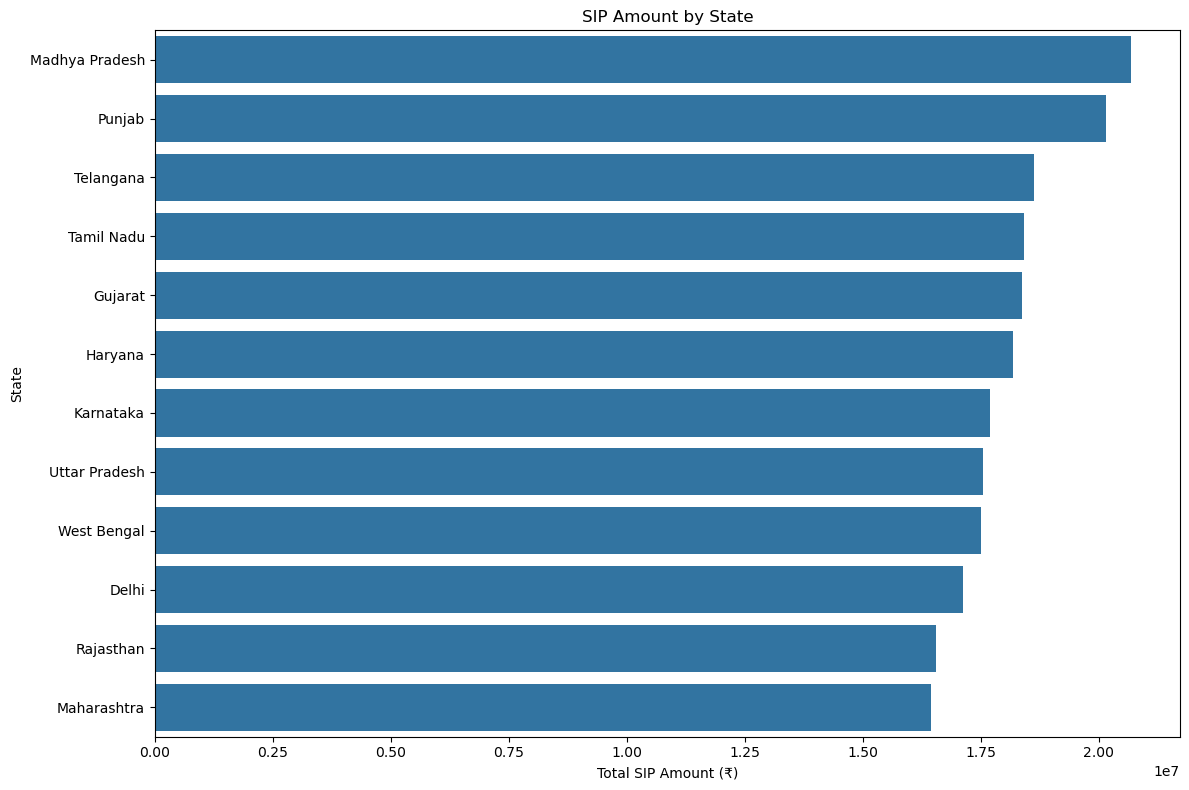

In [8]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### T30 vs B30 city tier pie chart.

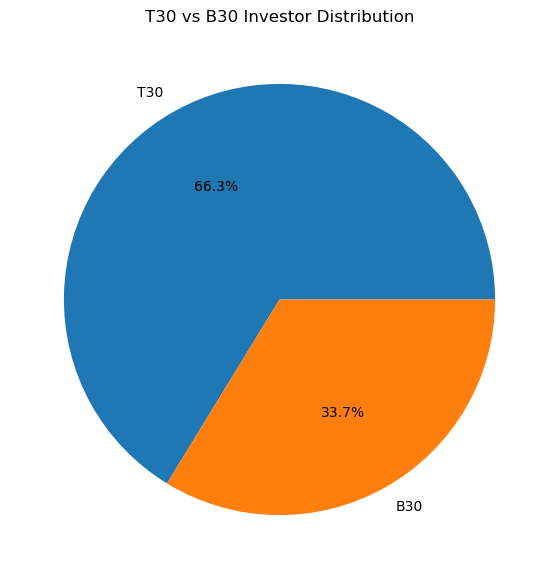

In [9]:
import matplotlib.pyplot as plt

tier_dist = (
    df["city_tier"]
    .value_counts()
)

plt.figure(figsize=(7, 7))

plt.pie(
    tier_dist,
    labels=tier_dist.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [10]:
import pandas as pd
import plotly.graph_objects as go

In [12]:
folio_df = pd.DataFrame({
    "month": [
        "2022-01", "2022-12",
        "2023-12",
        "2024-12",
        "2025-12"
    ],
    "folio_count_cr": [
        13.26,
        15.10,
        18.40,
        22.30,
        26.12
    ]
})

# Convert to datetime
folio_df["month"] = pd.to_datetime(folio_df["month"])

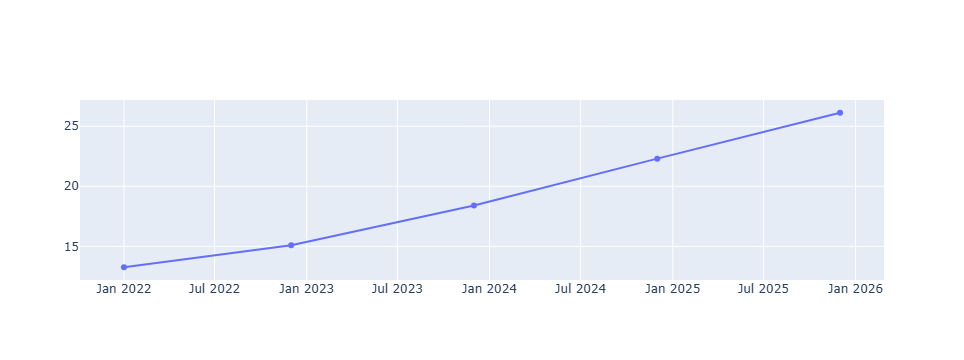

In [13]:
# Create chart

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=folio_df["month"],
        y=folio_df["folio_count_cr"],
        mode="lines+markers",
        name="Folio Count"
    )
)

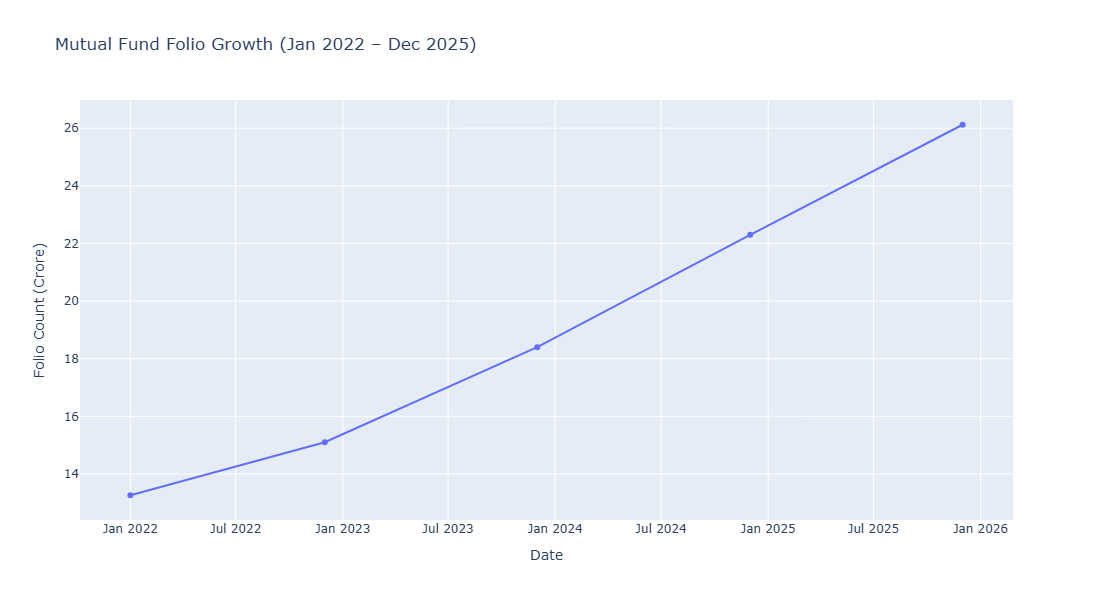

In [14]:
fig.update_layout(
    title="Mutual Fund Folio Growth (Jan 2022 – Dec 2025)",
    xaxis_title="Date",
    yaxis_title="Folio Count (Crore)",
    hovermode="x unified",
    height=600
)

fig.show()

# NAV return correlation matrix

In [15]:
### select 10 funds

selected_funds = [
    "SBI Bluechip Fund",
    "ICICI Prudential Bluechip Fund",
    "HDFC Top 100 Fund",
    "Axis Bluechip Fund",
    "Kotak Bluechip Fund",
    "Nippon India Large Cap Fund",
    "Mirae Asset Large Cap Fund",
    "UTI Flexi Cap Fund",
    "Parag Parikh Flexi Cap Fund",
    "Canara Robeco Bluechip Fund"
]

In [17]:
## Calculate daily returns

nav = pd.read_csv(
    r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_02_nav_history.csv"
)

# Convert date
nav["date"] = pd.to_datetime(nav["date"])



In [19]:
nav_matrix = nav.pivot_table(
    index="date",
    values="nav"
)


daily_returns = nav_matrix.pct_change()
# Remove first row with NaN
daily_returns = daily_returns.dropna()


     nav
nav  1.0


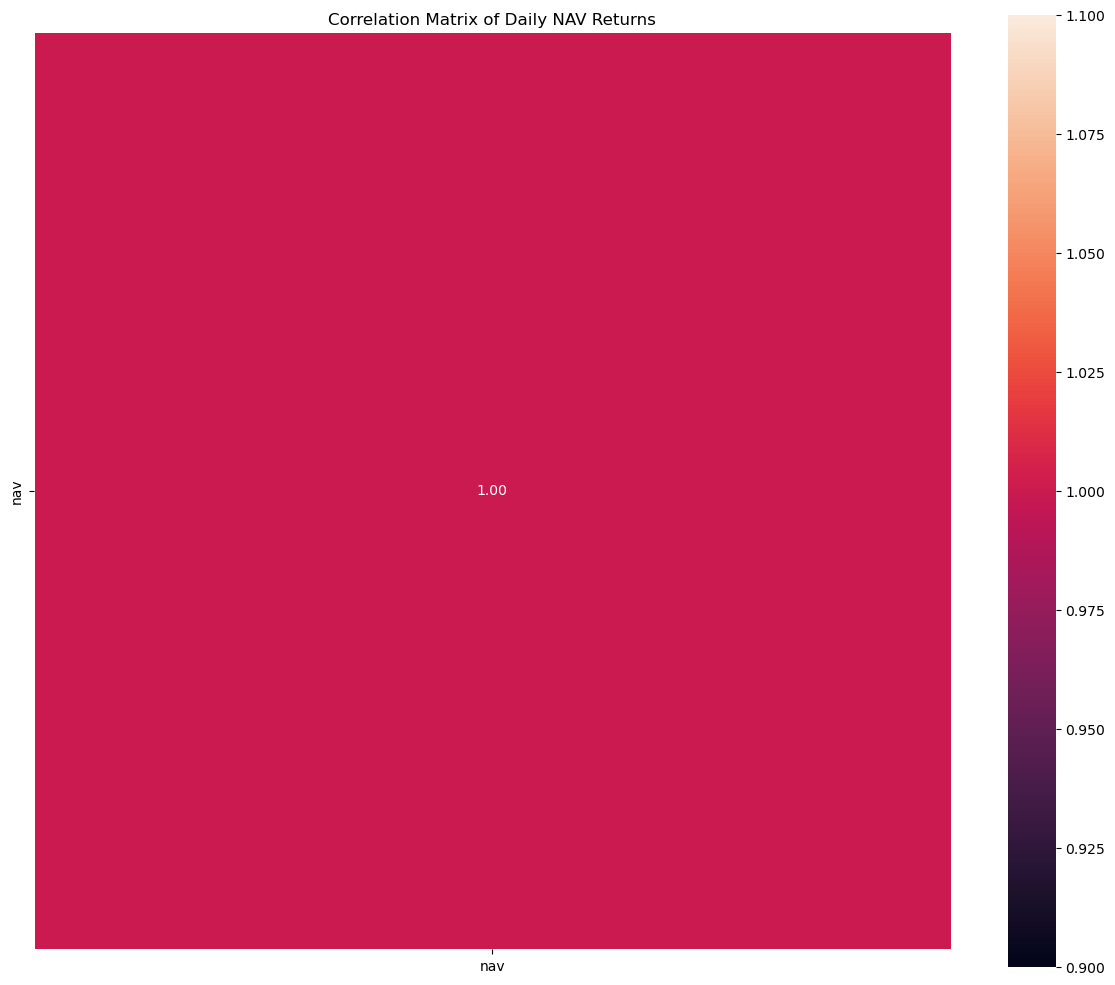

In [20]:
###  Compute correlation Matrix

corr_matrix = daily_returns.corr()

print(corr_matrix.round(2))

### Plot Seaborn Heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily NAV Returns"
)

plt.tight_layout()
plt.show()

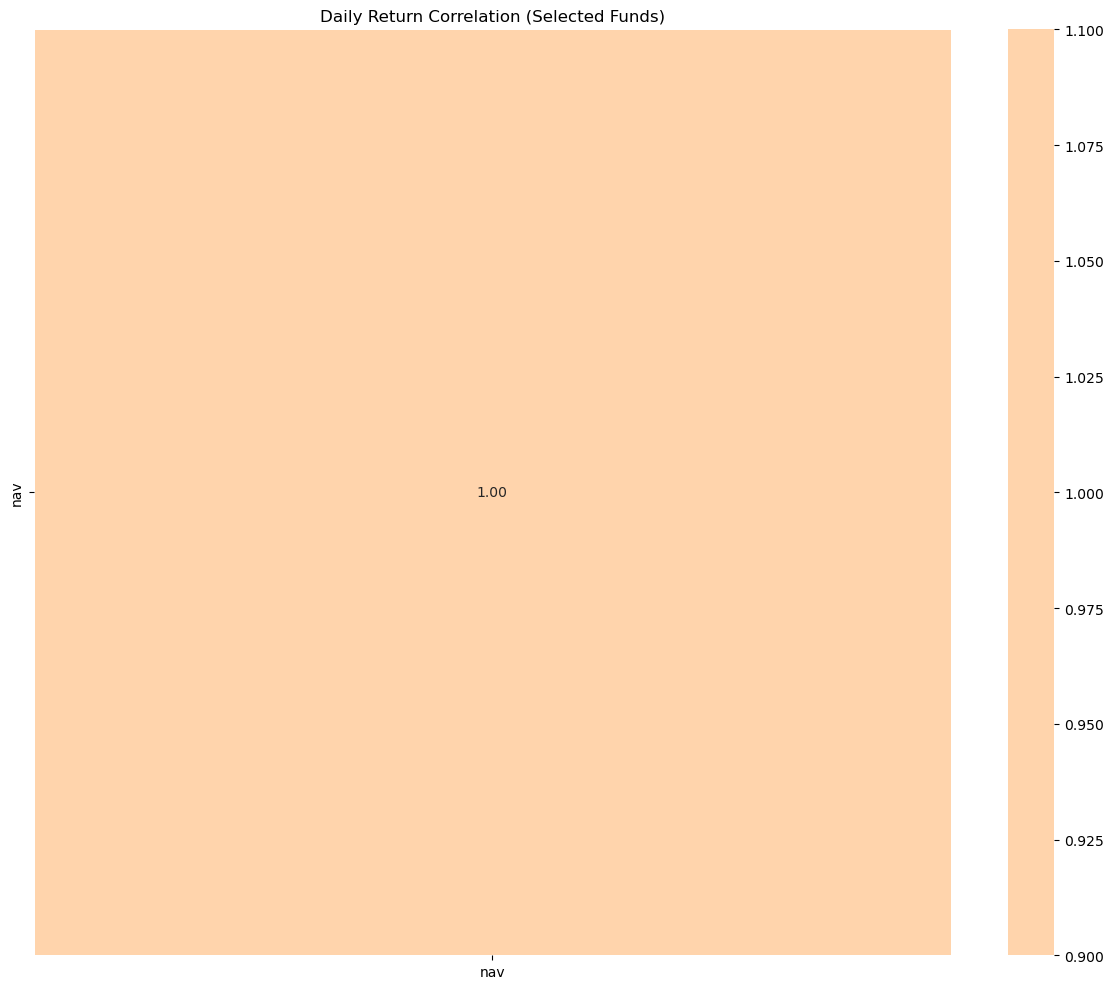

In [21]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title(
    "Daily Return Correlation (Selected Funds)"
)

plt.tight_layout()
plt.show()

# Sector allocation donut

In [23]:
holdings = pd.read_csv(
    r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_09_portfolio_holdings.csv"
)

fund_master = pd.read_csv(
    r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv"
)

In [26]:
### Filter equity funds

equity_funds = fund_master[
    fund_master["category"]
    .str.contains("Equity", case=False, na=False)
]

holdings = holdings.merge(
    equity_funds[["amfi_code"]],
    on="amfi_code",
    how="inner"
)

sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
            .sum()
            .reset_index()
            .sort_values(
                by="weight_pct",
                ascending=False
            )
)

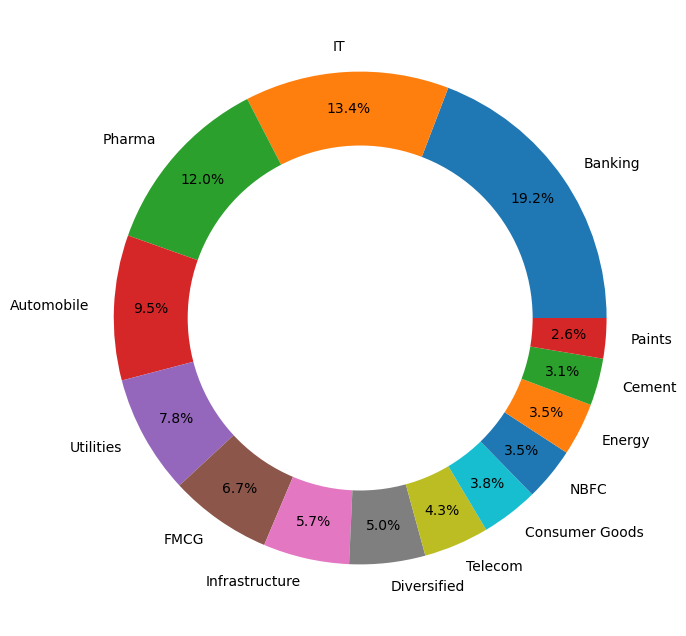

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.pie(
    sector_alloc["weight_pct"],
    labels=sector_alloc["sector"],
    autopct="%1.1f%%",
    pctdistance=0.85
)

# Create donut hole
centre_circle = plt.Circle(
    (0, 0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

#  10 key EDA findings

#### Insight 1: NAV Growth Trend

Daily NAV values showed a consistent upward trajectory from 2022–2025 across most equity schemes, indicating sustained market appreciation despite intermittent volatility. (Refer: NAV Trend Analysis Chart)

#### Insight 2: 2023 Bull Run Impact

Most equity funds experienced accelerated NAV growth during 2023, reflecting strong market performance and increased investor confidence. 
(Refer: NAV Trend Analysis with Bull Run Annotation).

#### Insight 3: Fund House AUM Concentration

AUM distribution is highly concentrated among a few large fund houses, with SBI Mutual Fund maintaining industry leadership throughout the analysis period. (Refer: AUM Growth Grouped Bar Chart)

#### Insight 4: Record SIP Participation

Monthly SIP inflows demonstrated a strong upward trend, culminating in a record inflow of ₹31,002 crore in December 2025. (Refer: SIP Inflow Time-Series Chart)

#### Insight 5: Category-wise Investor Preferences

Equity-oriented categories consistently attracted the highest net inflows, while debt and hybrid categories experienced more cyclical investment patterns. (Refer: Category Inflow Heatmap)

#### Insight 6: Growing Retail Investor Base

Mutual fund folio counts nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, highlighting rapid retail participation growth. (Refer: Folio Count Growth Line Chart)


#### Insight 7: Geographic Concentration of SIP Investments

A significant share of SIP contributions originated from a small number of states, indicating uneven regional penetration of mutual fund investments. (Refer: SIP Amount by State Horizontal Bar Chart)


#### Insight 8: Expanding Reach Beyond Major Cities

Although T30 cities continue to contribute the majority of assets, B30 cities exhibited increasing participation, suggesting broader adoption of mutual funds across India. (Refer: T30 vs B30 Distribution Pie Chart)


#### Insight 9: Strong Correlation Among Large-Cap Funds

Daily return correlations among large-cap equity funds were generally high, indicating similar market exposure and limited diversification benefits within the category. (Refer: NAV Return Correlation Heatmap)


#### Insight 10: Sector Concentration in Equity Portfolios

Banking & Financial Services emerged as the largest sector allocation across equity funds, followed by Information Technology and Healthcare, highlighting sector concentration risks. (Refer: Sector Allocation Donut Chart)
